In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor, plot_importance
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

print('Libraries loaded successfully')


In [ ]:
data = pd.read_csv('NIMS_Fatigue.csv')

print(f'Dataset shape: {data.shape}')
print('Columns:', data.columns.tolist())
print('\nMissing values:\n', data.isnull().sum())
data.head()


In [ ]:
# NT = Normalizing Temperature (C)
# QT = Quenching Temperature  (C)
# TT = Tempering Temperature  (C)
# All three are stored as ACTUAL TEMPERATURE VALUES, not binary flags.
# The model learns how each temperature affects mechanical properties.

print('Unique NT:', sorted(data['NT'].unique()))
print('Unique QT:', sorted(data['QT'].unique()))
print('Unique TT:', sorted(data['TT'].unique()))

ht_counts = data.groupby(['NT', 'QT', 'TT']).size().reset_index(name='count')
print(f'\n{len(ht_counts)} unique heat-treatment combinations:')
print(ht_counts.to_string(index=False))


In [ ]:
# NT, QT, TT are kept as temperature values -- that is how the model was
# trained, and what gives it predictive power over heat-treatment conditions.
features = ['C', 'Si', 'Mn', 'P', 'S', 'Ni', 'Cr', 'Cu', 'Mo', 'NT', 'TT', 'QT']
targets  = ['Tensile', 'Hardness', 'Fatigue']

X = data[features].astype(float)
y = data[targets].astype(float)

print(f'X shape: {X.shape}  |  y shape: {y.shape}')
print('\nTarget statistics:')
print(y.describe().round(2))


In [ ]:
xgb_model = XGBRegressor(random_state=42, tree_method='hist')

# Expanded grid vs original: added subsample, colsample_bytree
xgb_params = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}
print('Grid size:', 3*3*3*2*2)


In [ ]:
xgb_grid = GridSearchCV(
    xgb_model, xgb_params,
    cv=5,          # 5-fold instead of 3
    scoring='r2',
    n_jobs=-1,
    verbose=1,
)
xgb_grid.fit(X_train, y_train)

print('Best parameters:', xgb_grid.best_params_)
print(f'Best CV R2: {xgb_grid.best_score_:.4f}')


In [56]:
# Best model
best_xgb = xgb_grid.best_estimator_

In [57]:
# Save the trained model in JSON format
best_xgb.save_model('xgb_model.json')

In [58]:
# Load the model for inference
loaded_xgb = XGBRegressor()
loaded_xgb.load_model('xgb_model.json')

In [59]:
# Predictions
xgb_pred = best_xgb.predict(X_test)
loaded_pred = loaded_xgb.predict(X_test)

In [ ]:
def evaluate_model(y_true, y_pred, label='Model'):
    rows = []
    for i, target in enumerate(targets):
        r2   = r2_score(y_true.iloc[:, i], y_pred[:, i])
        mae  = mean_absolute_error(y_true.iloc[:, i], y_pred[:, i])
        rmse = mean_squared_error(y_true.iloc[:, i], y_pred[:, i]) ** 0.5
        mape = np.mean(np.abs((y_true.iloc[:, i] - y_pred[:, i]) / y_true.iloc[:, i])) * 100
        rows.append({'Target': target, 'R2': round(r2, 4),
                     'MAE': round(mae, 2), 'RMSE': round(rmse, 2),
                     'MAPE(%)': round(mape, 2)})
    df = pd.DataFrame(rows).set_index('Target')
    print(f'\n{label} -- test-set performance:')
    print(df.to_string())
    return df

eval_df = evaluate_model(y_test, xgb_pred, 'XGBoost (best)')


<Figure size 1000x600 with 0 Axes>

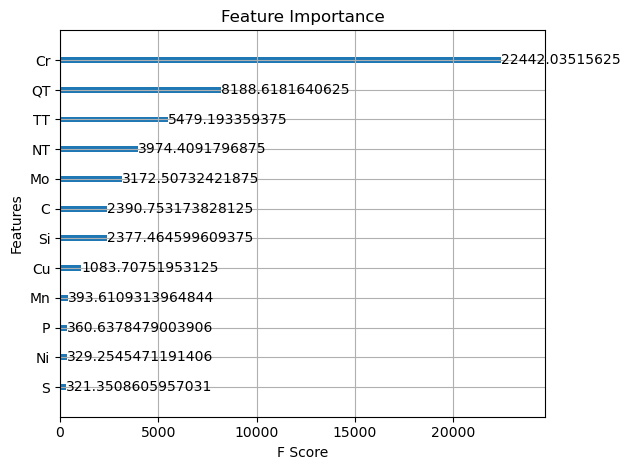

In [61]:
# Feature Importance plot
plt.figure(figsize=(10, 6))
plot_importance(best_xgb, importance_type='gain', title="Feature Importance", xlabel="F Score", ylabel="Features")
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

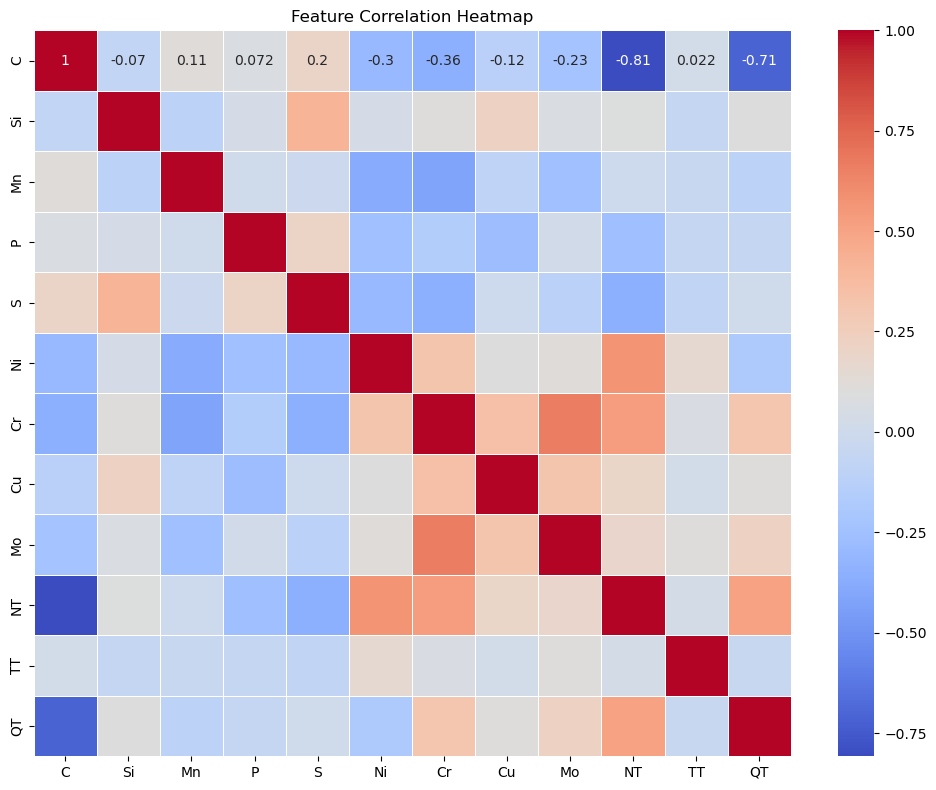

In [62]:
# Correlation Heatmap for feature interactions
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('feature_correlation_heatmap.png')
plt.show()

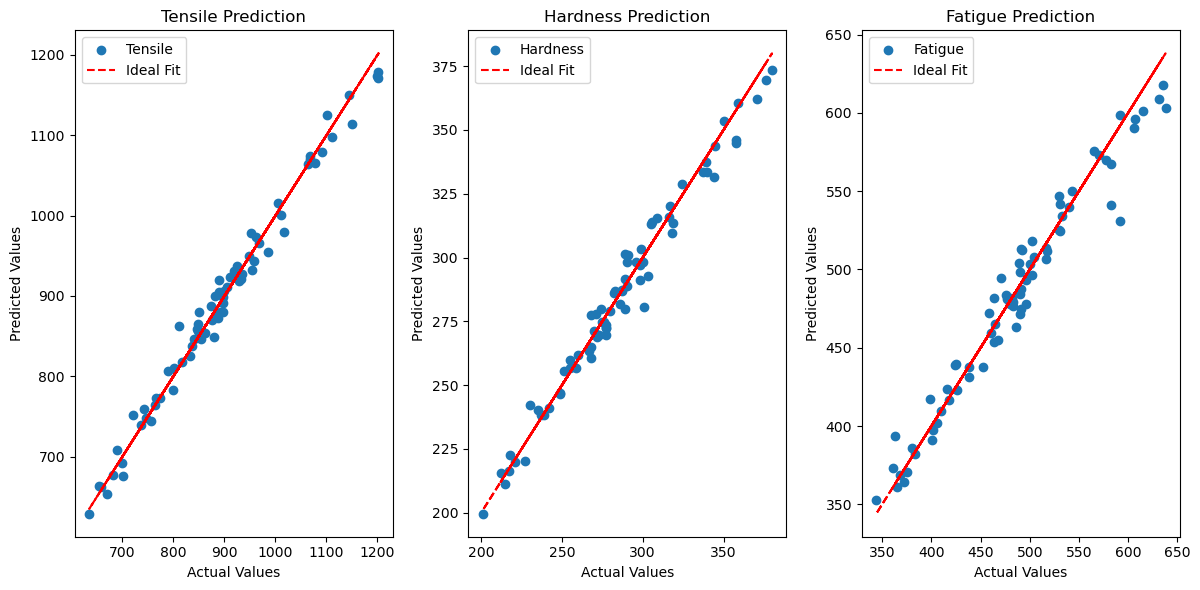

In [63]:
# Scatter plot for predicted vs actual values
plt.figure(figsize=(12, 6))
for i, target in enumerate(targets):
    plt.subplot(1, 3, i+1)
    plt.scatter(y_test[target], xgb_pred[:, i], label=target)
    plt.plot(y_test[target], y_test[target], 'r--', label='Ideal Fit')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{target} Prediction')
    plt.legend()

plt.tight_layout()
plt.savefig('predicted_vs_actual.png')
plt.show()

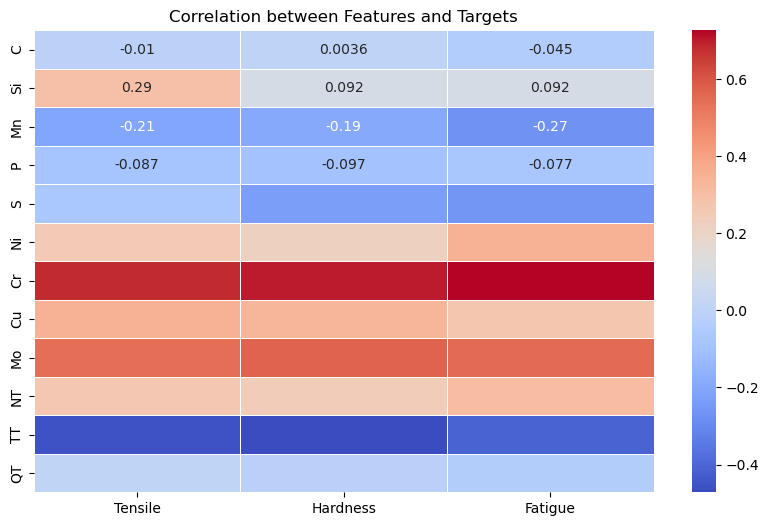

In [64]:
# Compute the correlation matrix between features and targets
corr_matrix = pd.concat([data[features], data[targets]], axis=1).corr()

# Extract only the correlations between the features and targets
target_feature_corr = corr_matrix.loc[features, targets]

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(target_feature_corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation between Features and Targets')
plt.show()


C:\Users\Abdulsamad\Documents\Upload_Intelligence\sample_project_1\env\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Abdulsamad\Documents\Upload_Intelligence\sample_project_1\env\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Abdulsamad\Documents\Upload_Intelligence\sample_project_1\env\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


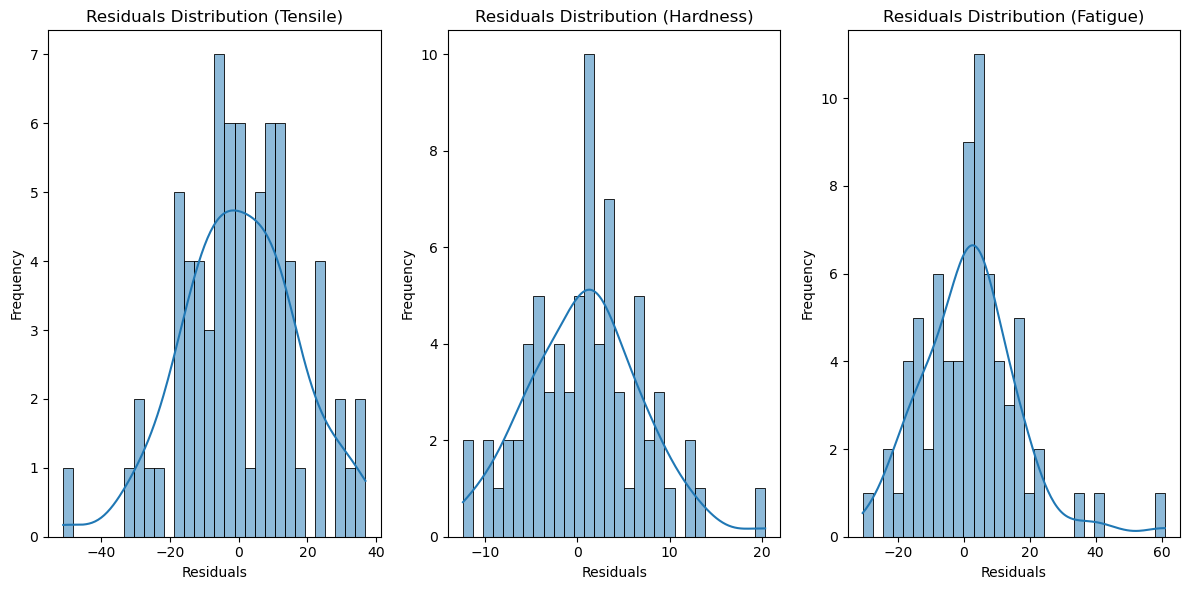

In [65]:
# Residuals plot
plt.figure(figsize=(12, 6))
for i, target in enumerate(targets):
    residuals = y_test[target] - xgb_pred[:, i]
    plt.subplot(1, 3, i+1)
    sns.histplot(residuals, bins=30, kde=True)
    plt.title(f'Residuals Distribution ({target})')
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('residuals_distribution.png')
plt.show()


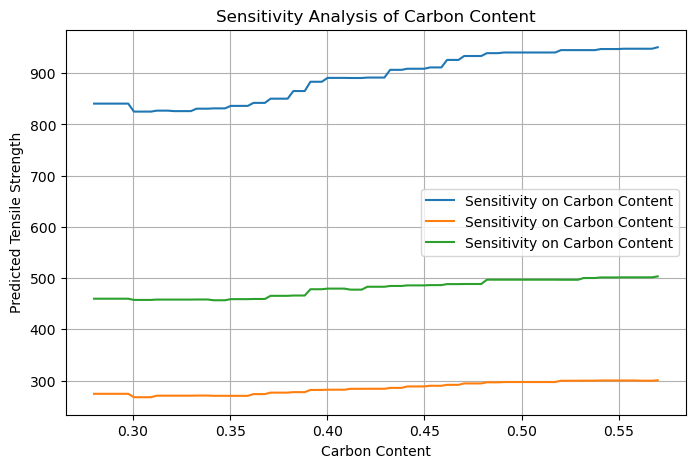

In [66]:
# Sensitivity Analysis
def sensitivity_analysis(model, X_test, feature, feature_name):
    """Perform sensitivity analysis by slightly varying the feature values."""
    X_copy = X_test.copy()
    variations = np.linspace(X_test[feature].min(), X_test[feature].max(), 100)
    predictions = []

    for val in variations:
        X_copy[feature] = val
        predictions.append(model.predict(X_copy))

    plt.figure(figsize=(8, 5))
    plt.plot(variations, np.mean(predictions, axis=1), label=f'Sensitivity on {feature_name}')
    plt.title(f'Sensitivity Analysis of {feature_name}')
    plt.xlabel(f'{feature_name}')
    plt.ylabel('Predicted Tensile Strength')
    plt.grid(True)
    plt.legend()
    plt.show()

sensitivity_analysis(best_xgb, X_test, 'C', 'Carbon Content')


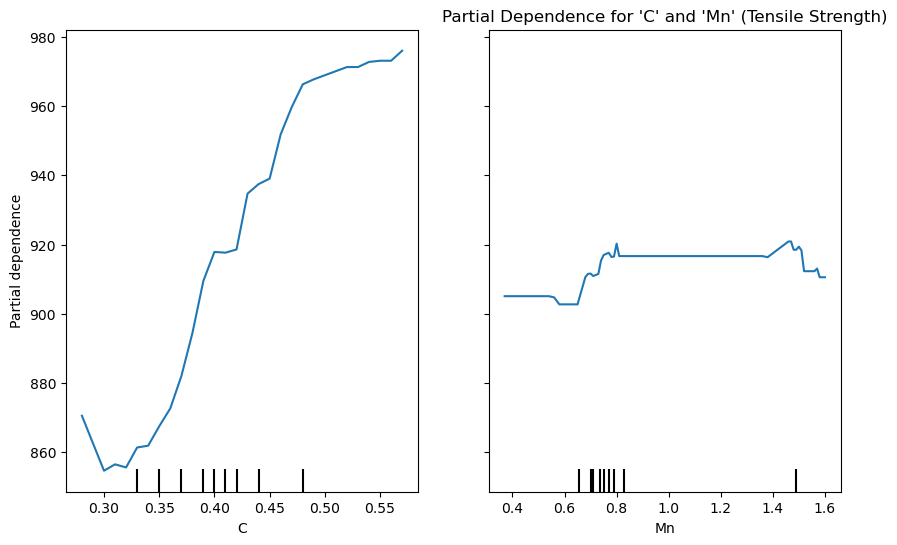

In [67]:
from sklearn.inspection import PartialDependenceDisplay

# Plot Partial Dependence for 'C' and 'Mn' for the first target (Tensile Strength)
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(best_xgb, X_train, features=['C', 'Mn'], target=0, grid_resolution=50, ax=ax)
plt.title("Partial Dependence for 'C' and 'Mn' (Tensile Strength)")
plt.show()

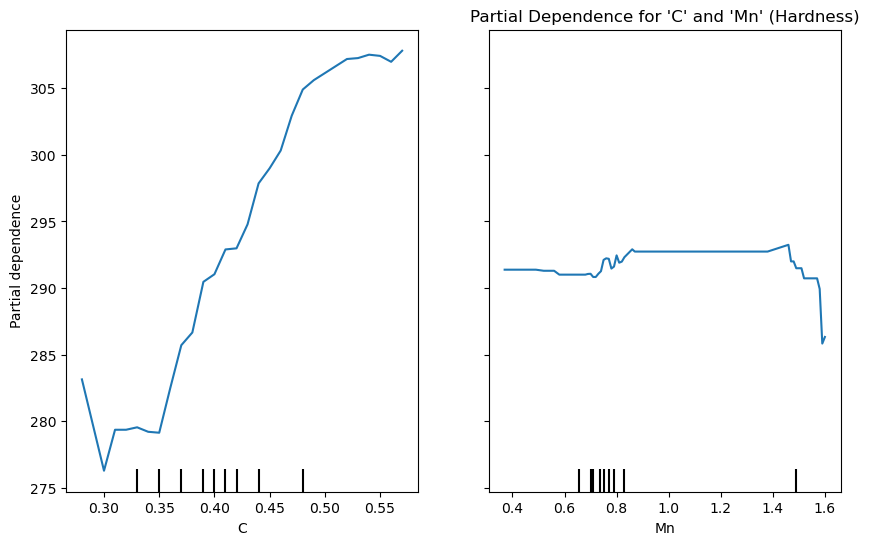

In [68]:
# For Hardness (second target), use target=1
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(best_xgb, X_train, features=['C', 'Mn'], target=1, grid_resolution=50, ax=ax)
plt.title("Partial Dependence for 'C' and 'Mn' (Hardness)")
plt.show()

In [ ]:
# Fatigue Strength is the THIRD target -- index 2, not 1
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(
    best_xgb, X_train, features=['C', 'Mn'],
    target=2,           # 0=Tensile, 1=Hardness, 2=Fatigue
    grid_resolution=50, ax=ax
)
plt.title("Partial Dependence for 'C' and 'Mn' (Fatigue Strength)")
plt.tight_layout()
plt.savefig('pdp_Fatigue.png', dpi=100)
plt.show()


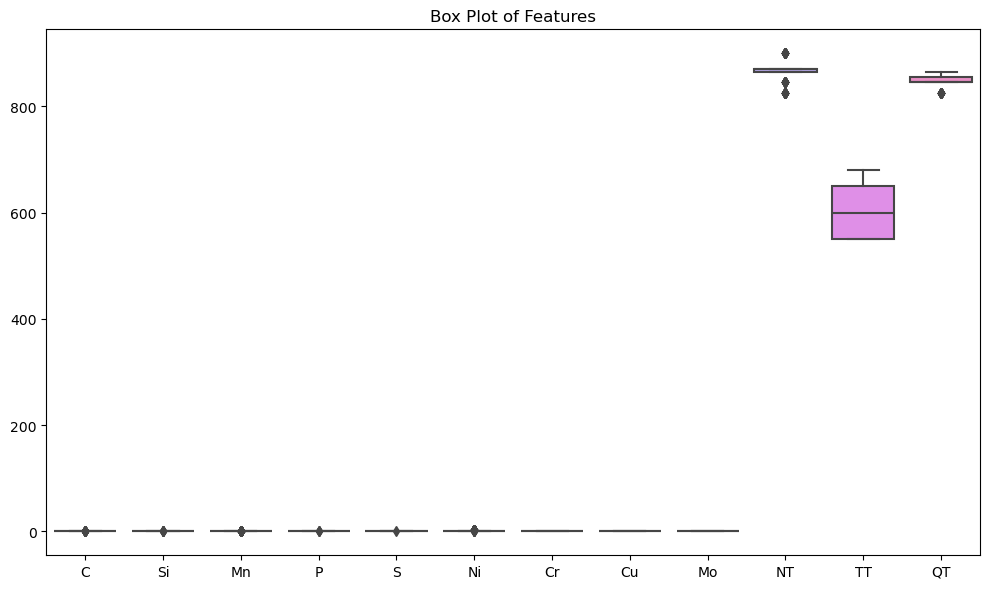

In [70]:
# Box Plot for Features
plt.figure(figsize=(10, 6))
sns.boxplot(data=X)
plt.title('Box Plot of Features')
plt.tight_layout()
plt.show()

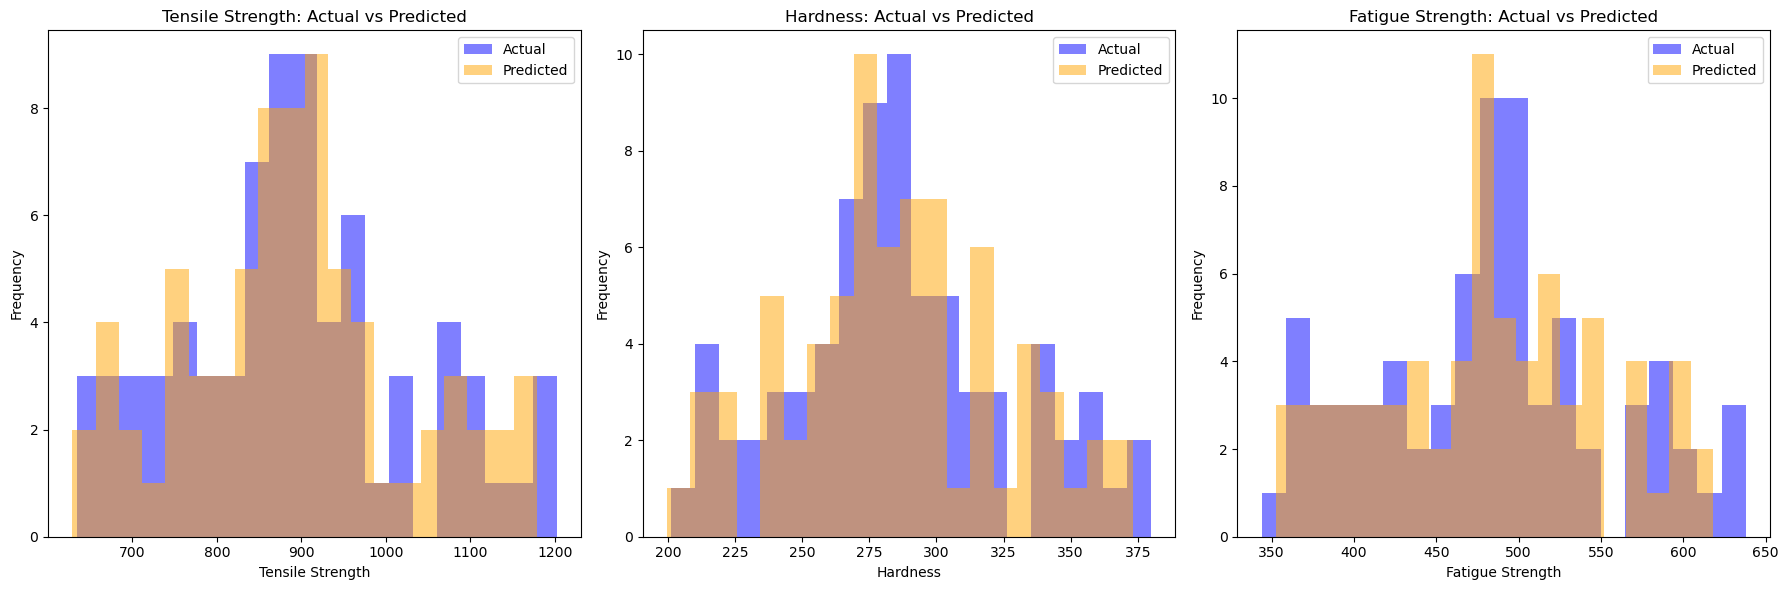

In [71]:
# Histograms of Actual vs Predicted values for each target
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Tensile Strength
axs[0].hist(y_test['Tensile'], alpha=0.5, label='Actual', bins=20, color='blue')
axs[0].hist(xgb_pred[:, 0], alpha=0.5, label='Predicted', bins=20, color='orange')
axs[0].set_title('Tensile Strength: Actual vs Predicted')
axs[0].set_xlabel('Tensile Strength')
axs[0].set_ylabel('Frequency')
axs[0].legend()

# Hardness
axs[1].hist(y_test['Hardness'], alpha=0.5, label='Actual', bins=20, color='blue')
axs[1].hist(xgb_pred[:, 1], alpha=0.5, label='Predicted', bins=20, color='orange')
axs[1].set_title('Hardness: Actual vs Predicted')
axs[1].set_xlabel('Hardness')
axs[1].set_ylabel('Frequency')
axs[1].legend()

# Fatigue Strength
axs[2].hist(y_test['Fatigue'], alpha=0.5, label='Actual', bins=20, color='blue')
axs[2].hist(xgb_pred[:, 2], alpha=0.5, label='Predicted', bins=20, color='orange')
axs[2].set_title('Fatigue Strength: Actual vs Predicted')
axs[2].set_xlabel('Fatigue Strength')
axs[2].set_ylabel('Frequency')
axs[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
from bokeh.plotting import figure, output_notebook, show
from bokeh.layouts import gridplot

output_notebook()

p1 = figure(width=400, height=400, title='C vs Predicted Tensile')
p1.circle(X_test['C'].values, xgb_pred[:, 0], size=8, color='navy', alpha=0.5)

p2 = figure(width=400, height=400, title='Mn vs Predicted Hardness')
p2.circle(X_test['Mn'].values, xgb_pred[:, 1], size=8, color='green', alpha=0.5)

# Fixed: index 2 for Fatigue (was 1 -- that is Hardness)
p3 = figure(width=400, height=400, title='Cu vs Predicted Fatigue')
p3.circle(X_test['Cu'].values, xgb_pred[:, 2], size=8, color='red', alpha=0.5)

grid = gridplot([[p1, p2], [p3, None]])
show(grid)


In [ ]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(y_test, y_pred, target_name):
    # Convert the regression problem into a binary classification problem using a threshold
    fpr, tpr, _ = roc_curve(y_test > np.median(y_test), y_pred)
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic - {target_name}')
    plt.legend(loc='lower right')
    plt.show()

# ROC-like curve for each target
plot_roc_curve(y_test['Tensile'], xgb_pred[:, 0], 'Tensile')
plot_roc_curve(y_test['Hardness'], xgb_pred[:, 1], 'Hardness')
plot_roc_curve(y_test['Fatigue'], xgb_pred[:, 2], 'Fatigue')

In [ ]:
from bokeh.plotting import figure, show
from bokeh.models import HoverTool
from bokeh.layouts import gridplot

# Create Bokeh plots for actual vs predicted values
def bokeh_scatter(y_actual, y_pred, target_name):
    p = figure(title=f'{target_name}: Actual vs Predicted', width=400, height=400)
    p.scatter(y_actual, y_pred, size=8, color="green", alpha=0.5)
    
    # Add hover tool
    hover = HoverTool()
    hover.tooltips = [
        ("Actual", "@x"),
        ("Predicted", "@y")
    ]
    p.add_tools(hover)
    
    p.xaxis.axis_label = 'Actual'
    p.yaxis.axis_label = 'Predicted'
    return p

# Create individual scatter plots
p1 = bokeh_scatter(y_test['Tensile'], xgb_pred[:, 0], 'Tensile')
p2 = bokeh_scatter(y_test['Hardness'], xgb_pred[:, 1], 'Hardness')
p3 = bokeh_scatter(y_test['Fatigue'], xgb_pred[:, 2], 'Fatigue')

# Arrange plots in grid
grid = gridplot([[p1, p2, p3]])
show(grid)
plt.savefig('bokeh.png')

In [ ]:
def sensitivity_analysis(model, X, feature, perturbation):
    # Perturb the feature
    X_perturbed = X.copy()
    X_perturbed[feature] += perturbation
    
    # Predict with the original and perturbed data
    original_pred = model.predict(X)
    perturbed_pred = model.predict(X_perturbed)
    
    # Compute the sensitivity as the change in predictions
    sensitivity = np.mean(np.abs(perturbed_pred - original_pred))
    return sensitivity

# Sensitivity for each feature
for feature in features:
    sensitivity = sensitivity_analysis(best_xgb, X_test, feature, perturbation=0.1)
    print(f"Sensitivity of {feature}: {sensitivity}")

In [ ]:
# Box plot for Actual vs Predicted values
fig, ax = plt.subplots(figsize=(10, 6))

data = [y_test['Tensile'], xgb_pred[:, 0], y_test['Hardness'], xgb_pred[:, 1], y_test['Fatigue'], xgb_pred[:, 2]]
labels = ['Actual Tensile', 'Predicted Tensile', 'Actual Hardness', 'Predicted Hardness', 'Actual Fatigue', 'Predicted Fatigue']

ax.boxplot(data, labels=labels)
ax.set_title("Box Plot of Actual vs Predicted Values")
plt.show()

In [ ]:
# Calculate the correlation between actual and predicted values
corr_data = pd.DataFrame({
    'Actual Tensile Strength': y_test['Tensile'],
    'Predicted Tensile Strength': xgb_pred[:, 0],
    'Actual Hardness': y_test['Hardness'],
    'Predicted Hardness': xgb_pred[:, 1],
    'Actual Fatigue Strength': y_test['Fatigue'],
    'Predicted Fatigue Strength': xgb_pred[:, 2]
})

# Plot heatmap
sns.heatmap(corr_data.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Actual vs Predicted Values')
plt.show()

In [ ]:
import shap

explainer   = shap.Explainer(best_xgb, X_train)
shap_values = explainer(X_test)   # shape: (n_samples, n_features, n_targets)
print('SHAP values shape:', shap_values.values.shape)


In [ ]:
# SHAP for Tensile Strength (index 0)
# NOTE: Do NOT scale SHAP values; they are already in the target's units.
shap_tensile = shap_values.values[:, :, 0]

print('Mean |SHAP| per feature (Tensile):')
importance = pd.Series(np.abs(shap_tensile).mean(axis=0), index=features)
print(importance.sort_values(ascending=False).round(3))

shap.summary_plot(shap_tensile, X_test, feature_names=features,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance -- Tensile Strength')
plt.tight_layout()
plt.savefig('SHAP_Tensile.png', dpi=100)
plt.show()


In [ ]:
# SHAP for Hardness (index 1)
shap_hardness = shap_values.values[:, :, 1]

shap.summary_plot(shap_hardness, X_test, feature_names=features,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance -- Hardness')
plt.tight_layout()
plt.savefig('SHAP_Hardness.png', dpi=100)
plt.show()


In [ ]:
# SHAP for Fatigue Strength (index 2)
shap_fatigue = shap_values.values[:, :, 2]

shap.summary_plot(shap_fatigue, X_test, feature_names=features,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance -- Fatigue Strength')
plt.tight_layout()
plt.savefig('SHAP_Fatigue.png', dpi=100)
plt.show()


In [ ]:
# Performance Summary
comparison_df = pd.DataFrame({
    'Actual Tensile Strength': y_test['Tensile'],
    'Predicted Tensile Strength (XGB)': xgb_pred[:, 0],
    'Predicted Tensile Strength (Loaded XGB)': loaded_pred[:, 0],
    'Actual Hardness': y_test['Hardness'],
    'Predicted Hardness (XGB)': xgb_pred[:, 1],
    'Predicted Hardness (Loaded XGB)': loaded_pred[:, 1],
    'Actual Fatigue Strength': y_test['Fatigue'],
    'Predicted Fatigue Strength (XGB)': xgb_pred[:, 2],
    'Predicted Fatigue Strength (Loaded XGB)': loaded_pred[:, 2]
})

print(comparison_df.head())


In [ ]:
# Prediction for new data
def predict_new_data(new_data):
    new_data = pd.DataFrame(new_data, index=[0])
    xgb_prediction = best_xgb.predict(new_data)
    loaded_prediction = loaded_xgb.predict(new_data)
    return xgb_prediction, loaded_prediction


In [ ]:
# IMPORTANT: NT, QT, TT must be ACTUAL TEMPERATURES (matching training data),
# NOT binary 0/1 flags. The original example used NT=1.0, TT=0, QT=0 which is wrong.
new_data = {
    'C':  0.40, 'Si': 0.97, 'Mn': 0.64, 'P': 0.020, 'S': 0.013,
    'Ni': 0.04, 'Cr': 0.01, 'Cu': 0.16, 'Mo': 0.00,
    'NT': 865,   # Normalizing temperature (C)
    'TT': 550,   # Tempering temperature  (C)
    'QT': 865,   # Quenching temperature  (C)
}

xgb_pred_new, loaded_pred_new = predict_new_data(new_data)

for label, pred in [('XGBoost', xgb_pred_new), ('Loaded', loaded_pred_new)]:
    t, h, f = pred[0]
    print(f'{label} -> Tensile: {t:.1f} MPa | Hardness: {h:.1f} HB | Fatigue: {f:.1f} MPa')
